Geodesic Distance Analysis of IMU Gravity Alignment

This script computes the geodesic angle between estimated gravity vectors
(from accelerometer data) and the ISB-defined downward direction.

It compares results before and after a coordinate transformation across datasets,
and visualizes the distribution using boxplots with overlaid datapoints.

In [1]:
# ==========================================================
# IMPORTS
# ==========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.patches import Patch


In [2]:
# ==========================================================
# USER INPUT
# ==========================================================
BEFORE_ROOT = "/Users/parth/Library/CloudStorage/Box-Box/WHT Datasets/01_columns_synced"
AFTER_ROOT  = "/Users/parth/Library/CloudStorage/Box-Box/WHT Datasets/02_coords_synced"

In [3]:
# ==========================================================
# CONSTANTS
# ==========================================================
G0 = 9.80665  # Gravity constant (m/s^2)
ISB_DOWN = np.array([0.0, -1.0, 0.0])  # ISB-defined downward direction

In [4]:
# ==========================================================
# COLUMN PATTERNS
# ==========================================================
COL_PATTERNS = {
    "acc": ("{p}_ACC_X", "{p}_ACC_Y", "{p}_ACC_Z"),
}

In [5]:
# ==========================================================
# HELPER FUNCTIONS
# ==========================================================
def normalize(v, eps=1e-12):
    """
    Normalize a vector with numerical stability.
    """
    norm = np.linalg.norm(v)
    return v / norm if norm > eps else v


def angle_to_down_deg(v):
    """
    Compute angle (in degrees) between a vector and ISB downward direction.
    """
    v = normalize(v)
    cos_theta = np.clip(np.dot(v, ISB_DOWN), -1.0, 1.0)
    return np.degrees(np.arccos(cos_theta))

In [6]:
# ==========================================================
# SENSOR PARSING
# ==========================================================
def build_sensors(df):
    """
    Identify accelerometer sensor triplets from dataframe columns.
    """
    prefixes = sorted({
        c.replace("_ACC_X", "") for c in df.columns if c.endswith("_ACC_X")
    })

    sensors = {}
    available_cols = set(df.columns)

    for p in prefixes:
        acc_cols = tuple(pattern.format(p=p) for pattern in COL_PATTERNS["acc"])
        if all(col in available_cols for col in acc_cols):
            sensors[p] = acc_cols

    return sensors

In [7]:
# ==========================================================
# STATIC WINDOW DETECTION
# ==========================================================
def find_static_window(acc, window_size=200, step=200):
    """
    Identify a low-variance window in accelerometer data,
    assumed to correspond to a static period.
    """
    N = len(acc)

    if N <= window_size:
        return 0, N

    best_score = np.inf
    best_window = (0, window_size)

    for start in range(0, N - window_size + 1, step):
        end = start + window_size
        segment = acc[start:end]

        score = np.mean(np.var(segment, axis=0))

        if score < best_score:
            best_score = score
            best_window = (start, end)

    return best_window

In [8]:
# ==========================================================
# SCALE DETECTION
# ==========================================================
def detect_scale(acc_segment):
    """
    Estimate scaling factor to normalize accelerometer magnitude to ~1g.
    """
    magnitudes = np.linalg.norm(acc_segment, axis=1)
    median_mag = np.median(magnitudes)

    if 0.3 <= median_mag <= 2.5:
        return 1.0
    elif 6.0 <= median_mag <= 14.0:
        return 1.0 / G0
    else:
        return 1.0 / median_mag

In [9]:
# ==========================================================
# STATIC VALIDATION
# ==========================================================
def is_valid_static(acc_window):
    """
    Validate whether a window represents a static segment.
    """
    variability = np.mean(np.std(acc_window, axis=0))
    magnitudes = np.linalg.norm(acc_window, axis=1)
    mean_mag = np.mean(magnitudes)

    return (variability < 0.05) and (0.7 < mean_mag < 1.3)

In [10]:
# ==========================================================
# FALLBACK GRAVITY ESTIMATION
# ==========================================================
def fallback_gravity_frame(acc):
    """
    Fallback gravity estimation using the most downward-pointing frame.
    """
    idx = np.argmin(acc[:, 1])  # Minimum Y corresponds to downward direction
    return acc[idx]

In [11]:
# ==========================================================
# FILE COLLECTION
# ==========================================================
def collect_csvs(root):
    dataset_map = defaultdict(list)

    for dirpath, _, filenames in os.walk(root):
        for f in filenames:
            if f.endswith(".csv"):
                full_path = os.path.join(dirpath, f)
                rel = os.path.relpath(full_path, root)
                dataset = rel.split(os.sep)[0]
                dataset_map[dataset].append(full_path)

    return dataset_map

In [12]:
# ==========================================================
# CORE COMPUTATION
# ==========================================================
def compute_geodesic(file_path):
    """
    Compute mean geodesic angle for all sensors in a file.
    """
    try:
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()

        # Downsample for efficiency
        df = df.iloc[::10]

        sensors = build_sensors(df)
        if not sensors:
            return None

        geodesic_angles = []

        for acc_cols in sensors.values():
            acc = df.loc[:, acc_cols].to_numpy(float)

            # Static window detection
            ws, we = find_static_window(acc)

            # Scaling
            scale = detect_scale(acc[ws:we])
            acc_static = acc[ws:we] * scale

            # Gravity estimation
            if is_valid_static(acc_static):
                gravity_vec = acc_static.mean(axis=0)
            else:
                scale_full = detect_scale(acc)
                acc_scaled = acc * scale_full
                gravity_vec = fallback_gravity_frame(acc_scaled)

            angle = angle_to_down_deg(gravity_vec)

            # Filter unrealistic orientations
            if angle <= 120:
                geodesic_angles.append(angle)

        if not geodesic_angles:
            return None

        return np.mean(geodesic_angles)

    except Exception:
        return None

In [13]:
# ==========================================================
# FILE COLLECTION
# ==========================================================
def collect_csvs(root_dir):
    """
    Recursively collect CSV files grouped by dataset.
    """
    dataset_map = defaultdict(list)

    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            if fname.endswith(".csv"):
                full_path = os.path.join(dirpath, fname)
                rel_path = os.path.relpath(full_path, root_dir)
                dataset_name = rel_path.split(os.sep)[0]
                dataset_map[dataset_name].append(full_path)

    return dataset_map

In [14]:
# ==========================================================
# MAIN PIPELINE
# ==========================================================
def main():
    before_map = collect_csvs(BEFORE_ROOT)
    after_map  = collect_csvs(AFTER_ROOT)

    common_datasets = sorted(set(before_map) & set(after_map))
    print(f"Found {len(common_datasets)} matching datasets")

    results = []

    for dataset in common_datasets:
        print(f"\nProcessing dataset: {dataset}")

        before_vals = []
        after_vals = []

        for f in before_map[dataset]:
            val = compute_geodesic(f)
            if val is not None and not np.isnan(val):
                before_vals.append(val)

        for f in after_map[dataset]:
            val = compute_geodesic(f)
            if val is not None and not np.isnan(val):
                after_vals.append(val)

        if not before_vals or not after_vals:
            print("Skipping dataset due to insufficient valid data")
            continue

        before_mean = np.mean(before_vals)
        after_mean = np.mean(after_vals)

        if np.isnan(before_mean) or np.isnan(after_mean):
            print("Skipping dataset due to NaN values")
            continue

        results.append((dataset, before_mean, after_mean))
        print(f"Before = {before_mean:.2f}, After = {after_mean:.2f}")

    plot_results(results)
    print_results(results)

In [15]:
# ==========================================================
# VISUALIZATION
# ==========================================================
def plot_results(results):
    """
    Generate boxplot with overlaid datapoints.
    """
    clean = [(d, b, a) for (d, b, a) in results if not (np.isnan(b) or np.isnan(a))]

    before_vals = [b for _, b, _ in clean]
    after_vals  = [a for _, _, a in clean]

    plt.rcParams.update({
        "font.size": 14,
        "font.family": "Avenir"
    })

    fig, ax = plt.subplots(figsize=(6, 6))

    bp = ax.boxplot(
        [before_vals, after_vals],
        labels=["Before", "After"],
        patch_artist=True,
        showfliers=False,
        whis=[0, 100],
        medianprops=dict(color="black", linewidth=2)
    )

    colors = ["#f4a261", "#4c72b0"]

    for box, color in zip(bp["boxes"], colors):
        box.set_facecolor(color)
        box.set_alpha(0.5)

    jitter = 0.05
    ax.scatter(1 + np.random.uniform(-jitter, jitter, len(before_vals)), before_vals)
    ax.scatter(2 + np.random.uniform(-jitter, jitter, len(after_vals)), after_vals)

    ax.set_ylabel("Geodesic distance to ISB gravity [deg]")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    legend_handles = [
        Patch(facecolor=colors[0], edgecolor="black", alpha=0.5, label="Before transformation"),
        Patch(facecolor=colors[1], edgecolor="black", alpha=0.5, label="After transformation"),
    ]

    ax.legend(handles=legend_handles, frameon=False, loc="upper right")

    plt.tight_layout()
    plt.show()

In [16]:
# ==========================================================
# OUTPUT
# ==========================================================
def print_results(results):
    """
    Print dataset-level summary.
    """
    print("\nDataset-level values:")
    for d, b, a in results:
        print(f"{d}: Before={b:.2f}, After={a:.2f}")

Found 5 matching datasets

Processing dataset: CAMARGO
Before = 52.51, After = 25.04

Processing dataset: HUGADB
Before = 61.86, After = 26.56

Processing dataset: NEWBEE
Before = 28.60, After = 29.03

Processing dataset: RealWorldHAR
Before = 73.94, After = 25.90

Processing dataset: YARETA
Before = 62.02, After = 27.64


/var/folders/th/vh466msn05j95h954__5fkq00000gn/T/ipykernel_1719/4213054044.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


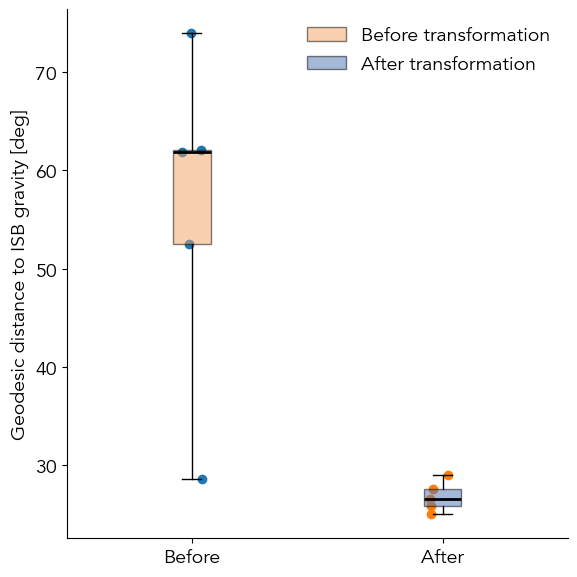


Dataset-level values:
CAMARGO: Before=52.51, After=25.04
HUGADB: Before=61.86, After=26.56
NEWBEE: Before=28.60, After=29.03
RealWorldHAR: Before=73.94, After=25.90
YARETA: Before=62.02, After=27.64


In [17]:
# ==========================================================
# ENTRY POINT
# ==========================================================
if __name__ == "__main__":
    main()